In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp
# из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# первых производных в (8.96)
def Oscillator(t, z):
    # инициализация массива, используемого для
    # хранения значений первых производных

    # инициализация массива, используемого для
    # хранения значений первых производных
    dy = np.zeros(2)

    dy[0] = z[1]
    dy[1] = -a / L * Gg**2 * np.cos(Gg * t) * np.sin(z[0]) - g / L * np.sin(z[0])

    return dy

In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# значения координат узлов ВС,
# использованной для вычисления
# численного решения СДУ (8.67)
# x=x(t), y=y(t)
def Solv_ODE(phi0, dphi_dt0, Tmax, t):
    # вычисление численного решения СДУ (8.67)
    # в узлах ВС, координаты которых
    # размещены в массиве t
    Solv = solve_ivp(
        Oscillator,
        [0, Tmax],
        [phi0, dphi_dt0],
        t_eval=t,
        method="RK45",
        rtol=1e-8,
        atol=1e-8,
    )

    # размещение значений координат узлов
    # временной сетки, на которой найдены численные решения
    # системы ОДУ (8.67) в массив t
    t = Solv.t

    # размещение мгновенных значений
    # угла отклонения математического маятника
    # от вертикали в массив phi
    phi = Solv.y[0, :]

    # размещение мгновенных значений
    # угловой скорости математического маятника
    # составляющей скорости в массив dphi_dt
    dphi_dt = Solv.y[1, :]

    return phi, dphi_dt

In [4]:
# Ячейка № 4

# задание функции, возвращающей
# значения декартовых координат
# маятника с колеблющейся точкой подвеса
def Coordinates(phi):
    # определение числа узлов временной сетки
    Np1 = len(phi)

    # инициализация массивов, используемых
    # для хранения мгновенных значений
    # декартовых координат и энергии математического маятника.
    x1 = np.zeros(Np1)
    y1 = np.zeros(Np1)

    # вычисление декартовых координат
    # математического маятника
    for i in range(Np1):
        # Квадрант I
        if (phi[i] >= 0) & (phi[i] >= np.pi / 2):
            x1[i] = L * np.sin(np.pi - phi[i])
            y1[i] = L * np.cos(np.pi - phi[i])
        # Квадрант II
        if (phi[i] < 0) & (np.abs(phi[i]) >= np.pi / 2):
            x1[i] = -L * np.sin(np.pi - np.abs(phi[i]))
            y1[i] = L * np.cos(np.pi - np.abs(phi[i]))
        # Квадрант III
        if (phi[i] < 0) & (np.abs(phi[i]) < np.pi / 2):
            x1[i] = -L * np.sin(np.abs(phi[i]))
            y1[i] = -L * np.cos(np.abs(phi[i]))
        # Квадрант IV
        if (phi[i] > 0) & (phi[i] <= np.pi / 2):
            x1[i] = L * np.sin(phi[i])
            y1[i] = -L * np.cos(phi[i])
        y1[i] = y1[i] + a * np.sin(Gg * t[i])

    return x1, y1

In [5]:
# Ячейка № 5

# задание значения
# ускорения свободного падения
g = 9.8

# задание длины маятника
L = 0.5

# задание амплитуды
# колебаний точки подвеса
a = 0.1

# задание частоты
# колебаний точки подвеса
Gg = 50

# задание начального
# угла отклонения
# математического маятника от вертикали
phi0 = np.pi * 0.1

# задание начального
# значения угловой скорости
# математического маятника
dphi_dt0 = 0

# задание длительности
# временного интервала,
# на котором вычисляется
# численное решение СДУ (8.96)
N = 10**5
Tmax = 20

# задание ВС, в узлах которой
# вычисляется численное решение СДУ (8.67)
t = np.linspace(0, Tmax, N)

# вычисление численного решения СДУ (8.96)
phi, dphi_dt = Solv_ODE(phi0, dphi_dt0, Tmax, t)

# вычисление координат маятника
# с учетом номера квадранта,
# в находится маятник
x, y = Coordinates(phi)

# вычисление зависимости
# эффективной энергии
# математического маятника
# от угла отклонения
# от вертикали
K = a**2 * Gg**2 / (4 * g * L)
phi_u = np.arange(-np.pi, np.pi, 2 * np.pi / 10**3)
U = -np.cos(phi_u) + K * np.cos(phi_u) ** 2


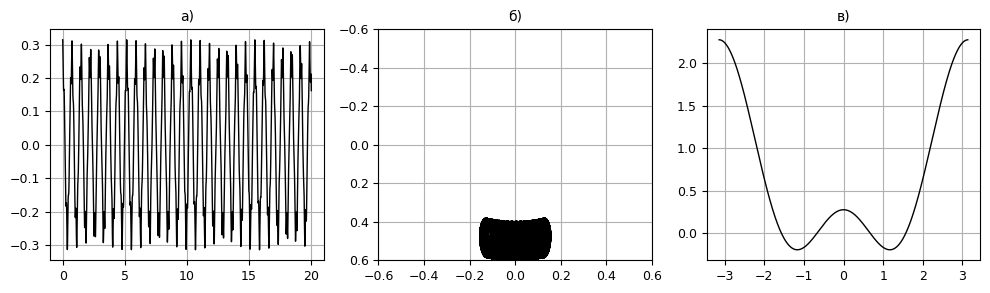

In [6]:
# Ячейка № 6

# визуализация зависимостей углов,
# угловых скоростей и угловых
# ускорений от времени, траекторий
# движения маятника с различными
# начальными условиями и
# соответствующей зависимости
# эффективной энергии от
# угла отклонения маятника
# от вертикали

fig = plt.figure(figsize=(12, 3))

# визуализация зависимостей угла
# отклонения маятника от оси OY
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(t, phi, "-k", lw=1)
ax1.grid(True)
ax1.tick_params(labelsize=9)
ax1.set_title("а)", fontsize=10)

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(x, -y, "black")
ax2.set_ylim(0.6, -0.6)
ax2.set_xlim(-0.6, 0.6)
ax2.tick_params(labelsize=9)
ax2.grid(True)
ax2.set_title("б)", fontsize=10)

ax3 = fig.add_subplot(1, 3, 3)
ax3.grid(True)
ax3.tick_params(labelsize=9)
ax3.set_title("в)", fontsize=10)
plt.plot(phi_u, U, "-k", lw=1)

plt.show()